In [27]:
%load_ext autoreload
%autoreload 2
import wandb
import numpy as np
from multistyleseg.charts.parallel_plot import parallel_coordinates_highlighted
from multistyleseg.charts.consts import ROOT_FIGURES
import matplotlib.pyplot as plt

api = wandb.Api()


runs = api.runs("liv4d-polytechnique/Baseline Fundus Segmentation")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import wandb
import pandas as pd

api = wandb.Api()
# Replace with your actual project path if different
runs = api.runs("liv4d-polytechnique/Baseline Fundus Segmentation")

res_list = []

for run in runs:
    # We create a dictionary for each run containing its name/ID
    # and the specific metrics logged in its 'summary'
    run_info = {
        "RETLES": run.summary.get("MeanIoU RETLES_split_1"),
        "IDRID": run.summary.get("MeanIoU IDRID_test"),
        "DDR": run.summary.get("MeanIoU DDR_test"),
        "MESSIDOR": run.summary.get("MeanIoU MESSIDOR_test"),
        "FGADR": run.summary.get("MeanIoU FGADR_split_1"),
        "Loss": run.config.get("loss_type"),
        "DA": run.config.get("data_augmentation_type"),
        "Image size": run.config.get("img_size")[0],
    }
    res_list.append(run_info)

# Create DataFrame
df = pd.DataFrame(res_list)

# Drop rows that are entirely empty (except for the Run Name)
df = df.dropna(subset=["RETLES", "IDRID", "DDR", "MESSIDOR", "FGADR"], how="all")


In [3]:
df.to_clipboard()

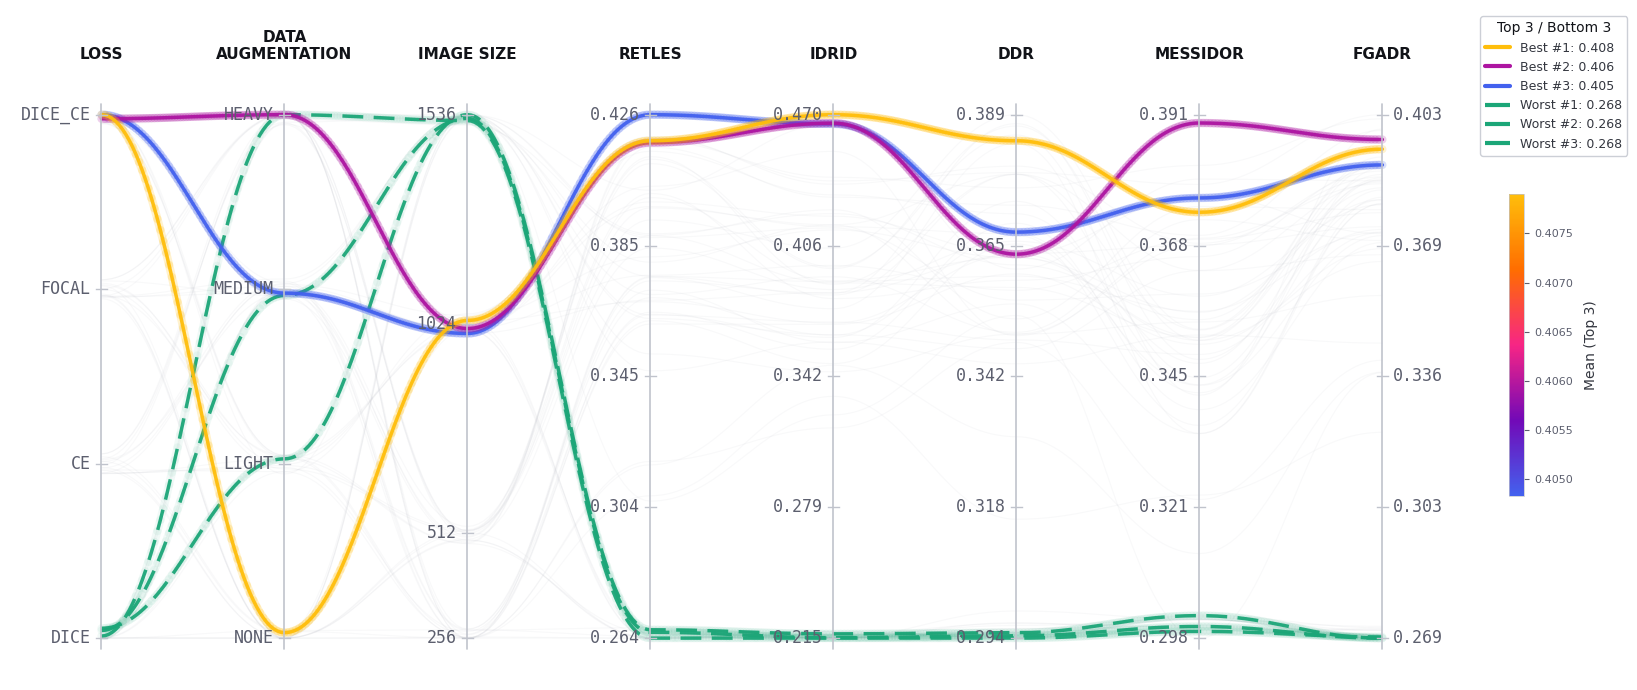

In [ ]:
# Fill empty DA with "none"
df["Data\nAugmentation"] = df["DA"].fillna("none")

# Compute a mean score for coloring
df["Mean"] = df[["RETLES", "IDRID", "DDR", "MESSIDOR", "FGADR"]].mean(axis=1)

# Define the dimensions
loss_map = {"DICE": 0, "CE": 1, "FOCAL": 2, "DICE_CE": 3}
da_map = {"none": 0, "light": 1, "medium": 2, "heavy": 3}
size_map = {256: 0, 512: 1, 1024: 2, 1536: 3}

dataset_cols = ["RETLES", "IDRID", "DDR", "MESSIDOR", "FGADR"]

dimensions = [
    {
        "name": "Loss",
        "values": df["Loss"].map(loss_map).values,
        "tickvals": list(loss_map.values()),
        "ticktext": list(loss_map.keys()),
    },
    {
        "name": "Data\nAugmentation",
        "values": df["Data\nAugmentation"].map(da_map).values,
        "tickvals": list(da_map.values()),
        "ticktext": list(da_map.keys()),
    },
    {
        "name": "Image size",
        "values": df["Image size"].values,
        "tickvals": list(size_map.keys()),
        "ticktext": [str(s) for s in size_map.keys()],
    },
]

# One axis per dataset
for col in dataset_cols:
    vals = df[col].values
    ticks = np.linspace(vals.min(), vals.max(), 5)
    dimensions.append(
        {
            "name": col,
            "values": vals,
            "tickvals": ticks.tolist(),
            "ticktext": [f"{v:.3f}" for v in ticks],
        }
    )

# Still need a scalar for coloring/ranking — mean works well here
df["Mean"] = df[dataset_cols].mean(axis=1)

fig, ax = parallel_coordinates_highlighted(
    df,
    dimensions,
    color_col="Mean",
    top_n=3,
    figsize=(18, 7),
    bottom_n=3,
    dark=False,
)
fig.savefig(ROOT_FIGURES / "parallel_plot.png", dpi=300, bbox_inches="tight")

In [25]:
df.to_clipboard()